<a href="https://colab.research.google.com/github/kdbuck4/Westford_Resilience/blob/main/westford_drivetime_analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Westford Drive Time Analysis
**Purpose:** Calculate drive times from every residential parcel to the nearest 3 locations in each destination category:
- Parks & Recreation
- Medical Facilities
- Schools
- Emergency Services

**Method:** OSMnx road network + NetworkX shortest-path routing (drive time in minutes)


## 1. Install & Import Dependencies

In [1]:
# Install required packages
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['osmnx', 'networkx', 'geopandas', 'pandas', 'openpyxl',
            'geopy', 'shapely', 'numpy', 'tqdm', 'folium', 'matplotlib']:
    pip_install(pkg)

print('All packages installed.')

All packages installed.


In [2]:
import os, time, warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import networkx as nx
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from shapely.geometry import Point
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster

warnings.filterwarnings('ignore')
ox.settings.log_console = False
ox.settings.use_cache = True

print('Imports successful.')

Imports successful.


## 2. Mount Google Drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Confirm mount succeeded and show top-level folders
import os
base = '/content/drive/MyDrive'
print('Drive mounted. Top-level folders:')
for f in sorted(os.listdir(base)):
    print(f'  {f}')

Mounted at /content/drive
Drive mounted. Top-level folders:
  AI Prompts
  Adobe Scan Apr 3, 2025.pdf
  Blank_I-9UVMRemoteHireNotice.pdf
  Buck 570 Slattery Rd Fletcher roof quote.rtf
  Buck 570 Slattery Rd Fletcher roof quote.rtf.gdoc
  Buck Binder.pdf
  Buck Tractor_signed.pdf
  Career
  Colab Notebooks
  Collin Buck_NMS_Essay.gdoc
  Copy of Kyle_Buck_CV.docx
  Copy of Steve_SS_Statement2025.pdf
  Dogs
  DrivewayPermit.pdf
  Elementary School Performance Nov 7th 2025.gdoc
  Farm
  Forms-Info
  Health Records
  House
  I-9 Form for Remote Hire.pdf
  I-9 Form for Remote Hire_20250808-0802.pdf
  I-9 Form for Remote Hire_20250808-0802_20250808-0803.pdf
  Kids
  MMU Project Grad mock invoice.pdf
  MMU Project_Grad 2026.gsheet
  Papers-Transfer
  Pics
  PrintablePaymentHistory.pdf
  Project Grad
  RIC KB.pdf
  Random-Fun
  Running
  SNHU
  Saved from Chrome
  Saved from Chrome (1)
  Steve_SS_Statement2025.pdf
  Student enrollment form release (2).pdf
  Taxes
  Tractor
  UVM
  Vehicle Info


## 3. Configuration — Set File Paths

```
My Drive/
└── Westford_DriveTime/
    ├── inputs/
    │   ├── residential_parcels.xlsx
    │   ├── parks_recreation.xlsx
    │   ├── medical_facilities.xlsx
    │   ├── schools.xlsx
    │   └── emergency_services.xlsx
    └── outputs/          ← results will be saved here
```

In [6]:
import os

inputs_dir = '/content/drive/MyDrive/Westford_DriveTime/inputs'
print(f"Folder exists: {os.path.exists(inputs_dir)}")
print("\nFiles found:")
if os.path.exists(inputs_dir):
    for f in sorted(os.listdir(inputs_dir)):
        full = os.path.join(inputs_dir, f)
        size = os.path.getsize(full)
        print(f"  {f}  ({size:,} bytes)")
else:
    print("  FOLDER NOT FOUND — check your DRIVE_ROOT path")

Folder exists: True

Files found:
  emergency_services.xlsx  (11,120 bytes)
  emergency_services_old.xlsx.gsheet  (172 bytes)
  medical_facilities.xlsx.gsheet  (172 bytes)
  parks_recreation.xlsx.gsheet  (172 bytes)
  residential_parcels.xlsx  (142,961 bytes)
  schools.xlsx.gsheet  (172 bytes)


In [17]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_ROOT    = '/content/drive/MyDrive/Westford_DriveTime'
INPUTS_DIR    = f'{DRIVE_ROOT}/inputs'
OUTPUTS_DIR   = f'{DRIVE_ROOT}/outputs'

os.makedirs(OUTPUTS_DIR, exist_ok=True)

CONFIG = {
    'residential_parcels': f'{INPUTS_DIR}/residential_parcels.xlsx',
    'parks_recreation':    f'{INPUTS_DIR}/parks_recreation.xlsx',
    'medical_facilities':  f'{INPUTS_DIR}/medical_facilities.xlsx',
    'schools':             f'{INPUTS_DIR}/schools.xlsx',
    'emergency_services':  f'{INPUTS_DIR}/emergency_services.xlsx',

    'address_col': 'Site Address',
    'name_col':    'Owner',
    'lat_col':     'Centroid Lat',
    'lon_col':     'Centroid Lon',

    'top_n':         3,
    'place_name':    'Westford, Massachusetts, USA',
    'network_type':  'drive',
    'speed_kmh':     50,

    'output_excel':  f'{OUTPUTS_DIR}/westford_drivetime_results.xlsx',
    'output_map':    f'{OUTPUTS_DIR}/westford_drivetime_map.html',
    'output_chart':  f'{OUTPUTS_DIR}/westford_summary_chart.png',
}

TOP_N = CONFIG['top_n']
CATEGORIES = {
    'parks_recreation':    'Parks and Recreation',
    'medical_facilities':  'Medical Facilities',
    'schools':             'Schools',
    'emergency_services':  'Emergency Services',
}

print('Checking input files...')
all_keys = ['residential_parcels'] + list(CATEGORIES.keys())
missing = []
for key in all_keys:
    path = CONFIG.get(key, '')
    status = 'OK  ' if os.path.exists(path) else 'MISSING'
    print(f'  [{status}] {key}: {path}')
    if status == 'MISSING':
        missing.append(key)

if missing:
    print(f'\nWARNING: {len(missing)} file(s) not found. Check paths above before continuing.')
else:
    print('\nAll input files found. Ready to run.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking input files...
  [OK  ] residential_parcels: /content/drive/MyDrive/Westford_DriveTime/inputs/residential_parcels.xlsx
  [OK  ] parks_recreation: /content/drive/MyDrive/Westford_DriveTime/inputs/parks_recreation.xlsx
  [OK  ] medical_facilities: /content/drive/MyDrive/Westford_DriveTime/inputs/medical_facilities.xlsx
  [OK  ] schools: /content/drive/MyDrive/Westford_DriveTime/inputs/schools.xlsx
  [OK  ] emergency_services: /content/drive/MyDrive/Westford_DriveTime/inputs/emergency_services.xlsx

All input files found. Ready to run.


## 3. Helper Functions

In [25]:
geolocator = Nominatim(user_agent='westford_drivetime_analysis', timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.1, error_wait_seconds=5)

def geocode_address(address: str):
    try:
        location = geocode(address)
        if location:
            return location.latitude, location.longitude
    except Exception as e:
        print(f'  Geocoding error for "{address}": {e}')
    return None, None

def read_excel_smart(filepath):
    peek = pd.read_excel(filepath, engine='openpyxl', header=None, nrows=5)
    header_row = 0
    for i, row in peek.iterrows():
        non_null = row.dropna()
        if len(non_null) > len(row) / 2 and all(isinstance(v, str) for v in non_null):
            header_row = i
            break
    return pd.read_excel(filepath, engine='openpyxl', header=header_row)

def load_and_geocode(filepath: str, label: str) -> pd.DataFrame:
    lat_col = CONFIG['lat_col']
    lon_col = CONFIG['lon_col']

    print(f'\nLoading {label} → {filepath}')
    df = read_excel_smart(filepath)
    print(f'  Loaded {len(df):,} rows. Columns: {list(df.columns)}')

    # Normalise column names to lowercase for matching
    df.columns = df.columns.str.strip()
    df_lower = {c.lower(): c for c in df.columns}  # lowercase → original name map

    # ── Detect address column: accept any of these names ──
    ADDR_CANDIDATES = ['address', 'site address', 'street address', 'full address', 'location']
    addr_col = None
    for candidate in ADDR_CANDIDATES:
        if candidate in df_lower:
            addr_col = df_lower[candidate]
            break
    if addr_col is None:
        raise KeyError(
            f'No address column found in {label}. '
            f'Columns present: {list(df.columns)}. '
            f'Expected one of: {ADDR_CANDIDATES}'
        )

    # ── Detect name column ──
    NAME_CANDIDATES = ['name', 'owner', 'facility name', 'site name', 'place name']
    name_col = None
    for candidate in NAME_CANDIDATES:
        if candidate in df_lower:
            name_col = df_lower[candidate]
            break
    if name_col is None:
        df['name'] = df[addr_col]
        name_col = 'name'

    # ── Detect lat/lon (case-insensitive) ──
    lat_actual = df_lower.get(lat_col.lower())
    lon_actual = df_lower.get(lon_col.lower())

    if lat_actual and lon_actual:
        print(f'  Pre-geocoded lat/lon columns found — skipping geocoding.')
        df = df.rename(columns={lat_actual: 'lat', lon_actual: 'lon'})
    else:
        print(f'  Geocoding {len(df):,} addresses (this may take a while)...')
        df['lat'] = np.nan
        df['lon'] = np.nan
        for i, row in tqdm(df.iterrows(), total=len(df), desc=f'  Geocoding {label}'):
            lat, lon = geocode_address(str(row[addr_col]))
            df.at[i, 'lat'] = lat
            df.at[i, 'lon'] = lon

    before = len(df)
    df = df.dropna(subset=['lat', 'lon'])
    print(f'  {len(df):,}/{before:,} rows have valid coordinates.')

    df = df.rename(columns={name_col: 'name', addr_col: 'address'})
    return df


# ── Graph helpers ──────────────────────────────────────────────────────────
def nearest_node(G, lat, lon):
    return ox.distance.nearest_nodes(G, X=lon, Y=lat)

def drive_time_minutes(G, orig_node, dest_node, weight='travel_time'):
    try:
        t = nx.shortest_path_length(G, orig_node, dest_node, weight=weight)
        return round(t / 60, 2)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return np.nan

print('Helper functions defined.')

Helper functions defined.


In [24]:
def read_excel_smart(filepath):
    """Read Excel, skipping any leading note/blank rows to find the real header."""
    # Peek at first 5 rows without a header
    peek = pd.read_excel(filepath, engine='openpyxl', header=None, nrows=5)
    # The real header row is the first row where >half the cells are non-null strings
    header_row = 0
    for i, row in peek.iterrows():
        non_null = row.dropna()
        if len(non_null) > len(row) / 2 and all(isinstance(v, str) for v in non_null):
            header_row = i
            break
    return pd.read_excel(filepath, engine='openpyxl', header=header_row)

## 4. Download the Westford Road Network

(This downloads from OpenStreetMap — may take 1-3 minutes on first run, then cached)

Network loaded: 1,156 nodes, 2,962 edges


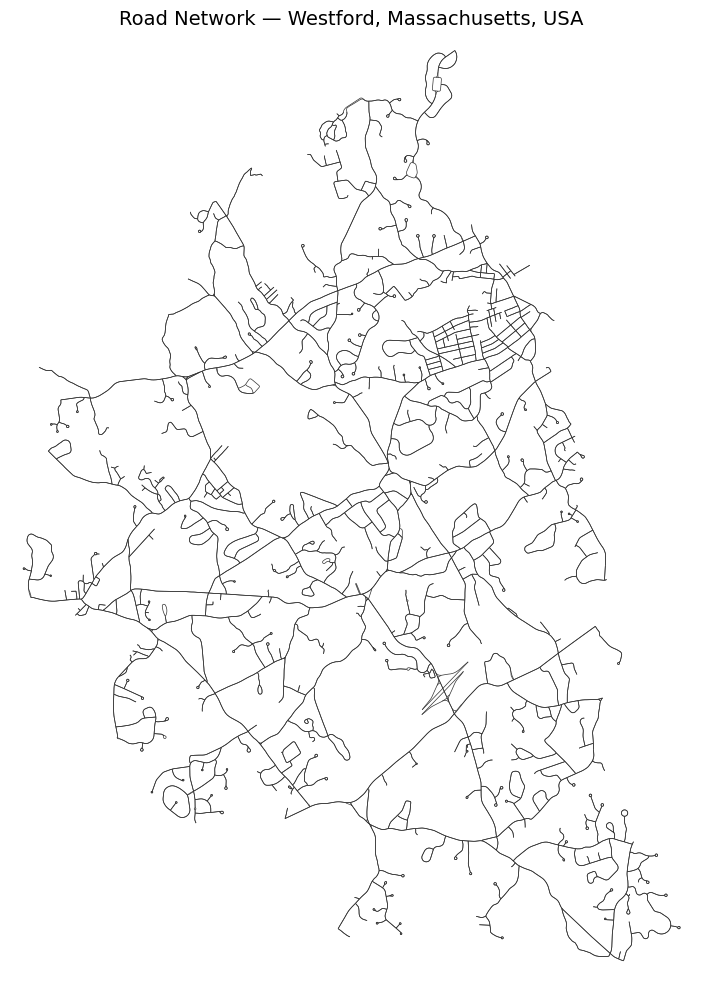

In [19]:
print(f'Downloading road network for: {CONFIG["place_name"]}')
print('(This downloads from OpenStreetMap — may take 1-3 minutes on first run, then cached)')

G = ox.graph_from_place(
    CONFIG['place_name'],
    network_type=CONFIG['network_type'],
    simplify=True
)

# Add travel time (seconds) to each edge based on speed and length
G = ox.add_edge_speeds(G, fallback=CONFIG['speed_kmh'])
G = ox.add_edge_travel_times(G)

nodes, edges = ox.graph_to_gdfs(G)
print(f'\nNetwork loaded: {len(nodes):,} nodes, {len(edges):,} edges')

# Quick plot of the network
fig, ax = ox.plot_graph(G, figsize=(10, 10), node_size=0,
                        edge_color='#333333', edge_linewidth=0.5,
                        bgcolor='white', show=False, close=False)
ax.set_title(f'Road Network — {CONFIG["place_name"]}', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Load & Geocode All Address Datasets

In [26]:
# Load residential parcels (origins)
df_residential = load_and_geocode(CONFIG['residential_parcels'], 'Residential Parcels')

# Load each destination category
destinations = {}
for key, label in CATEGORIES.items():
    destinations[key] = load_and_geocode(CONFIG[key], label)

print('\n--- Summary ---')
print(f'  Residential parcels : {len(df_residential):,}')
for key, label in CATEGORIES.items():
    print(f'  {label:<30}: {len(destinations[key]):>4} locations')


Loading Residential Parcels → /content/drive/MyDrive/Westford_DriveTime/inputs/residential_parcels.xlsx
  Loaded 835 rows. Columns: ['Parcel Span', 'Property Type', 'Cat Code', 'Housing Units', 'Homestead Declared', 'Owner', 'Site Address', 'Mailing Address', 'Mailing City', 'Mailing State', 'Mailing Zip', 'Acres', 'Acres Computed', 'Real Value', 'Land Value', 'Improvement Value', 'Res Code', 'Match Status', 'Centroid Lat', 'Centroid Lon']
  Pre-geocoded lat/lon columns found — skipping geocoding.
  835/835 rows have valid coordinates.

Loading Parks and Recreation → /content/drive/MyDrive/Westford_DriveTime/inputs/parks_recreation.xlsx
  Loaded 347 rows. Columns: ['name', 'address', 'Facility Notes', 'Category', 'Street Address', 'City', 'State', 'ZIP', 'County', 'Operator / Owner']
  Geocoding 347 addresses (this may take a while)...


  Geocoding Parks and Recreation:   0%|          | 0/347 [00:00<?, ?it/s]

  278/347 rows have valid coordinates.

Loading Medical Facilities → /content/drive/MyDrive/Westford_DriveTime/inputs/medical_facilities.xlsx
  Loaded 182 rows. Columns: ['name', 'address', 'Facility Notes', 'Category', 'Street Address', 'City', 'State', 'ZIP', 'County', 'Operator / Owner']
  Geocoding 182 addresses (this may take a while)...


  Geocoding Medical Facilities:   0%|          | 0/182 [00:00<?, ?it/s]

  144/182 rows have valid coordinates.

Loading Schools → /content/drive/MyDrive/Westford_DriveTime/inputs/schools.xlsx
  Loaded 247 rows. Columns: ['name', 'address', 'Facility Notes', 'Category', 'Street Address', 'City', 'State', 'ZIP', 'County', 'Operator / Owner']
  Geocoding 247 addresses (this may take a while)...


  Geocoding Schools:   0%|          | 0/247 [00:00<?, ?it/s]

  184/247 rows have valid coordinates.

Loading Emergency Services → /content/drive/MyDrive/Westford_DriveTime/inputs/emergency_services.xlsx
  Loaded 55 rows. Columns: ['name', 'address', 'facility_notes', 'category', 'street_address', 'city', 'state', 'zip', 'county', 'operator']
  Geocoding 55 addresses (this may take a while)...


  Geocoding Emergency Services:   0%|          | 0/55 [00:00<?, ?it/s]

  49/55 rows have valid coordinates.

--- Summary ---
  Residential parcels : 835
  Parks and Recreation          :  278 locations
  Medical Facilities            :  144 locations
  Schools                       :  184 locations
  Emergency Services            :   49 locations


## 6. Map Each Address to the Nearest Graph Node

In [2]:
print('Snapping addresses to road network nodes...')

# Snap residential parcels
df_residential['node'] = ox.distance.nearest_nodes(
    G,
    X=df_residential['lon'].values,
    Y=df_residential['lat'].values
)

# Snap destination points
for key in CATEGORIES:
    df = destinations[key]
    df['node'] = ox.distance.nearest_nodes(
        G,
        X=df['lon'].values,
        Y=df['lat'].values
    )
    destinations[key] = df

print('Done. All points snapped to network nodes.')

Snapping addresses to road network nodes...


NameError: name 'ox' is not defined

## 7. Run Drive Time Analysis
>

In [1]:
def compute_nearest_n(G, origins_df, destinations_df, category_label, top_n=3):
    """
    For every origin parcel, compute drive time to every destination,
    then return the top_n nearest destinations with their travel times.
    Returns a DataFrame with one row per origin.
    """
    results = []
    dest_nodes = destinations_df['node'].tolist()
    dest_names = destinations_df['name'].tolist()
    dest_addrs = destinations_df.get('address', destinations_df['name']).tolist() \
                 if 'address' in destinations_df.columns else dest_names

    for _, row in tqdm(origins_df.iterrows(), total=len(origins_df),
                       desc=f'  {category_label}'):
        orig_node = row['node']
        times = []
        for d_node, d_name, d_addr in zip(dest_nodes, dest_names, dest_addrs):
            t = drive_time_minutes(G, orig_node, d_node)
            times.append((t, d_name, d_addr))

        # Sort by travel time, pick top N
        times.sort(key=lambda x: (x[0] is np.nan or np.isnan(x[0]), x[0]))
        top = times[:top_n]

        record = {}
        # Identify origin
        for id_col in ['address', 'name', 'parcel_id', 'pid', 'id']:
            if id_col in row.index:
                record['origin_address'] = row[id_col]
                break
        record.setdefault('origin_address', str(row.name))
        record['origin_lat'] = row['lat']
        record['origin_lon'] = row['lon']

        for rank, (t, name, addr) in enumerate(top, start=1):
            record[f'{category_label}_rank{rank}_name']         = name
            record[f'{category_label}_rank{rank}_address']      = addr
            record[f'{category_label}_rank{rank}_drivetime_min'] = t

        results.append(record)

    return pd.DataFrame(results)


# Run for all categories
result_dfs = {}
for key, label in CATEGORIES.items():
    print(f'\nProcessing {label}...')
    result_dfs[key] = compute_nearest_n(
        G,
        df_residential,
        destinations[key],
        category_label=key,
        top_n=TOP_N
    )

print('\nAll categories complete!')

NameError: name 'CATEGORIES' is not defined

## 8. Merge Results into a Single Table

In [ ]:
# All result DataFrames share origin_address / lat / lon — merge on those
base_cols = ['origin_address', 'origin_lat', 'origin_lon']

df_merged = result_dfs[list(CATEGORIES.keys())[0]][base_cols].copy()

for key in CATEGORIES:
    drop_cols = [c for c in base_cols if c in result_dfs[key].columns]
    extra = result_dfs[key].drop(columns=drop_cols)
    df_merged = pd.concat([df_merged, extra], axis=1)

print(f'Final results table: {df_merged.shape[0]:,} rows × {df_merged.shape[1]} columns')
df_merged.head(3)

## 9. Summary Statistics

In [ ]:
print('=' * 60)
print('DRIVE TIME SUMMARY  (nearest facility, minutes)')
print('=' * 60)

summary_rows = []
for key, label in CATEGORIES.items():
    col = f'{key}_rank1_drivetime_min'
    if col in df_merged.columns:
        s = df_merged[col].dropna()
        row = {
            'Category':  label,
            'Mean (min)': round(s.mean(), 2),
            'Median (min)': round(s.median(), 2),
            'Min (min)':  round(s.min(), 2),
            'Max (min)':  round(s.max(), 2),
            'P90 (min)':  round(s.quantile(0.90), 2),
            'No Path':    int(df_merged[col].isna().sum()),
        }
        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
cats = [r['Category'] for r in summary_rows]
means = [r['Mean (min)'] for r in summary_rows]
medians = [r['Median (min)'] for r in summary_rows]
x = np.arange(len(cats))
w = 0.35
ax.bar(x - w/2, means,   w, label='Mean',   color='steelblue')
ax.bar(x + w/2, medians, w, label='Median', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=11)
ax.set_ylabel('Drive Time (minutes)')
ax.set_title('Mean & Median Drive Time to Nearest Facility — Westford, MA')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(CONFIG['output_chart'], dpi=150)
plt.show()
print(f'Chart saved: {CONFIG["output_chart"]}')

## 10. Export Results to Excel

In [ ]:
output_path = CONFIG['output_excel']

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    # Main results — one row per parcel
    df_merged.to_excel(writer, sheet_name='All Results', index=False)

    # Summary sheet
    df_summary.to_excel(writer, sheet_name='Summary Stats', index=False)

    # One sheet per category showing top-N breakdown
    for key, label in CATEGORIES.items():
        cat_cols = ['origin_address', 'origin_lat', 'origin_lon'] + \
                   [c for c in df_merged.columns if c.startswith(key)]
        df_merged[cat_cols].to_excel(
            writer,
            sheet_name=label[:31],  # Excel sheet name limit
            index=False
        )

print(f'Results saved to: {output_path}')
print(f'Sheets: All Results | Summary Stats | {" | ".join(list(CATEGORIES.values())[:4])}')

## 11. Interactive Map (Optional)

In [ ]:
# Build an interactive Folium map showing parcels coloured by
# drive time to nearest facility (parks used as example)

center_lat = df_residential['lat'].mean()
center_lon = df_residential['lon'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=13,
               tiles='CartoDB positron')

CATEGORY_COLORS = {
    'parks_recreation':   'green',
    'medical_facilities': 'red',
    'schools':            'blue',
    'emergency_services': 'orange',
}

# Add destination markers
for key, label in CATEGORIES.items():
    cluster = MarkerCluster(name=label).add_to(m)
    color = CATEGORY_COLORS[key]
    for _, row in destinations[key].iterrows():
        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=folium.Popup(f"<b>{label}</b><br>{row['name']}", max_width=200),
            icon=folium.Icon(color=color, icon='info-sign')
        ).add_to(cluster)

# Add residential parcels coloured by nearest parks drive time
col = 'parks_recreation_rank1_drivetime_min'
if col in df_merged.columns:
    max_t = df_merged[col].quantile(0.95)
    res_cluster = MarkerCluster(name='Residential Parcels').add_to(m)
    for _, row in df_merged.iterrows():
        t = row.get(col, np.nan)
        if pd.isna(t):
            c = 'gray'
        elif t < max_t * 0.33:
            c = 'darkgreen'
        elif t < max_t * 0.66:
            c = 'lightgreen'
        else:
            c = 'darkred'

        folium.CircleMarker(
            location=[row['origin_lat'], row['origin_lon']],
            radius=4,
            color=c,
            fill=True,
            fill_color=c,
            fill_opacity=0.7,
            popup=folium.Popup(
                f"<b>{row['origin_address']}</b><br>"
                f"Nearest park: {row.get('parks_recreation_rank1_name', 'N/A')}<br>"
                f"Drive time: {t} min",
                max_width=250
            )
        ).add_to(res_cluster)

folium.LayerControl().add_to(m)
m.save(CONFIG['output_map'])
print(f'Interactive map saved to: {CONFIG["output_map"]}')
m  # Renders inline in Jupyter

## 12. (Optional) Route Visualisation for a Single Parcel

In [ ]:
# Visualise the actual drive route from one parcel to its nearest school
# Change the index (0) to any parcel row you want to inspect

PARCEL_IDX = 0  # <-- change this
CATEGORY_KEY = 'schools'  # <-- change to any category key

origin_row = df_residential.iloc[PARCEL_IDX]
orig_node  = origin_row['node']

dest_df  = destinations[CATEGORY_KEY]
dest_row = dest_df.iloc[0]  # nearest destination (already sorted)
dest_node = dest_row['node']

try:
    route = nx.shortest_path(G, orig_node, dest_node, weight='travel_time')
    t_min = drive_time_minutes(G, orig_node, dest_node)
    print(f"Route: {origin_row.get('address', 'Parcel')} → {dest_row['name']}")
    print(f"Drive time: {t_min} minutes | {len(route)} nodes")

    fig, ax = ox.plot_graph_route(
        G, route,
        route_color='red', route_linewidth=4, route_alpha=0.8,
        node_size=0, bgcolor='white', figsize=(10, 10),
        show=False, close=False
    )
    ax.set_title(f'Drive Route to {dest_row["name"]} ({t_min} min)', fontsize=13)
    plt.tight_layout()
    plt.show()

except nx.NetworkXNoPath:
    print('No path found between these nodes. Try a different parcel index.')

---
## Done!

| Output File | Contents |
|---|---|
| `westford_drivetime_results.xlsx` | Full results table + per-category sheets + summary stats |
| `westford_drivetime_map.html` | Interactive map (open in any browser) |
| `westford_summary_chart.png` | Bar chart of mean/median drive times |

### Tips
- **Speed up geocoding:** If you already have lat/lon columns in your Excel files, set them in the `CONFIG` dict and geocoding will be skipped entirely.
- **Large datasets:** For 5,000+ parcels consider using `nx.single_source_dijkstra_path_length` with precomputed target node sets for a significant speedup.
- **Change network type:** Set `network_type` to `'walk'` to get walk-time analysis instead.